# SAIA Chat AI API - Test Notebook

Testing the GWDG Scalable AI Accelerator (SAIA) platform via its OpenAI-compatible API.

**Endpoint:** `https://chat-ai.academiccloud.de/v1`  
**Docs:** https://docs.hpc.gwdg.de/services/saia/index.html

In [4]:
# Store your API key securely — prefer environment variable over hardcoding
import os

API_KEY = os.environ.get("SAIA_API_KEY", "a80c8e8293a9826a995643cc46b9b015")
BASE_URL = "https://chat-ai.academiccloud.de/v1"

## 1. List available models

In [5]:
from openai import OpenAI

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

models = client.models.list()
for m in models.data:
    print(m.id)

INFO | HTTP Request: GET https://chat-ai.academiccloud.de/v1/models "HTTP/1.1 200 OK"


qwen3-coder-30b-a3b-instruct
glm-4.7
qwen3.6-35b-a3b
apertus-70b-instruct-2509
qwen3-omni-30b-a3b-instruct
devstral-2-123b-instruct-2512
internvl3.5-30b-a3b
qwen3.5-122b-a10b
qwen3.5-397b-a17b
gemma-4-31b-it
mistral-large-3-675b-instruct-2512
meta-llama-3.1-8b-instruct
openai-gpt-oss-120b
qwen3-30b-a3b-instruct-2507
medgemma-27b-it
deepseek-r1-distill-llama-70b
teuken-7b-instruct-research


## 2. Text completion API

In [4]:
MODEL = "mistral-large-3-675b-instruct-2512"

completion = client.completions.create(
    model=MODEL,
    prompt="San Francisco is a",
    max_tokens=50,
    temperature=0,
)

print(completion.choices[0].text)

 city of many nicknames, including "The City by the Bay", "Fog City", "San Fran", and "Frisco", as well as older ones like "The City that Knows How", "Baghdad by the Bay


## 3. Chat completion API

In [5]:
chat = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user",   "content": "How tall is the Eiffel Tower?"},
    ],
    temperature=0,
)

print(chat.choices[0].message.content)

The **Eiffel Tower** has the following height measurements:

- **Original height (1889):** 300 meters (984 feet)
- **With antennas (current height):** **330 meters (1,083 feet)** (as of the latest modifications)

The tower's height can vary slightly due to temperature changes (thermal expansion of the iron structure).

Would you like details on its construction or other fun facts? 😊


## 4. Try a different model — Qwen 2.5 72B

In [12]:
MODEL_LARGE = "mistral-large-3-675b-instruct-2512"

chat_large = client.chat.completions.create(
    model=MODEL_LARGE,
    messages=[
        {"role": "system", "content": "You are a climate science assistant."},
        {"role": "user",   "content": "Briefly explain ERA5-Land reanalysis data and its main use cases."},
    ],
    temperature=0.2,
    max_tokens=300,
)

print(chat_large.choices[0].message.content)

**ERA5-Land** is a high-resolution global atmospheric reanalysis dataset produced by the **European Centre for Medium-Range Weather Forecasts (ECMWF)** as part of the **Copernicus Climate Change Service (C3S)**. It is an enhanced version of the **ERA5** reanalysis, specifically designed to provide more detailed land-surface information.

### **Key Features of ERA5-Land:**
- **Spatial Resolution:** ~9 km (0.1° × 0.1°), finer than ERA5 (~31 km).
- **Temporal Resolution:** Hourly data from **1950 to present** (updated with a ~5-day delay).
- **Variables:** Includes land-surface parameters like **temperature, precipitation, soil moisture, runoff, snow depth, evaporation, and more**.
- **Forcing:** Driven by ERA5 atmospheric data but with improved land-surface modeling (HTESSEL scheme).
- **Consistency:** Long-term, globally complete dataset with reduced biases compared to observations.

### **Main Use Cases:**
1. **Climate Monitoring & Trend Analysis**
   - Studying long-term changes in te

**ERA5-Land** is a high-resolution global atmospheric reanalysis dataset produced by the **European Centre for Medium-Range Weather Forecasts (ECMWF)** as part of the **Copernicus Climate Change Service (C3S)**. It is an enhanced version of the **ERA5** reanalysis, specifically designed to provide more detailed land-surface information.

### **Key Features of ERA5-Land:**
- **Spatial Resolution:** ~9 km (0.1° × 0.1°), higher than ERA5 (~31 km).
- **Temporal Resolution:** Hourly data from **1950 to present** (updated with a ~5-day delay).
- **Variables:** Includes land-surface parameters like **temperature, precipitation, soil moisture, runoff, snow depth, evaporation, and more**.
- **Forcing:** Driven by ERA5 atmospheric data but with improved land-surface modeling (e.g., HTESSEL land-surface scheme).
- **Consistency:** Long-term, globally complete dataset with reduced biases compared to raw observations.

### **Main Use Cases:**
1. **Climate Monitoring & Trend Analysis**
   - Studying long-term changes in land-surface variables (e.g., droughts, heatwaves, snow cover).
   - Validating climate models and satellite observations.

2. **Hydrological & Agricultural Applications**
   - Assessing **soil moisture, evapotranspiration, and runoff** for water resource

## 5. Streaming response

In [ ]:
stream = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "List 5 key variables in climate data analysis."},
    ],
    stream=True,
)

for chunk in stream:
    delta = chunk.choices[0].delta.content
    if delta:
        print(delta, end="", flush=True)
print()  # newline at end

## 6. Image generation

Status: 200
{'created': 1781615505, 'data': [{'b64_json': '...', 'url': None, 'revised_prompt': None}]}


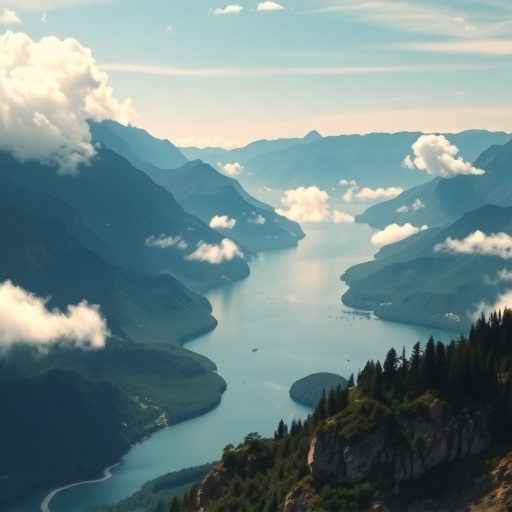

In [11]:
import requests
from IPython.display import Image, display
import base64

IMAGE_URL = "https://saia.gwdg.de/v1/images/generations"

resp = requests.post(
    IMAGE_URL,
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}",
    },
    json={
        "prompt": "A dreamy landscape with mountains and rivers",
        "size": "512x512",
    },
)

print("Status:", resp.status_code)
data = resp.json()
print(data)

if resp.ok and "data" in data and data["data"]:
    item = data["data"][0]
    url = item.get("url")
    b64 = item.get("b64_json")
    if url:
        img_bytes = requests.get(url).content
        display(Image(data=img_bytes))
    elif b64:
        display(Image(data=base64.b64decode(b64)))
    else:
        print("No image in response — full item:", item)

## 7. Token usage inspection

In [8]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "What is bias correction in climate modelling?"},
    ],
    temperature=0,
    max_tokens=200,
)

print(response.choices[0].message.content)
print("\n--- Token usage ---")
print(f"Prompt tokens:     {response.usage.prompt_tokens}")
print(f"Completion tokens: {response.usage.completion_tokens}")
print(f"Total tokens:      {response.usage.total_tokens}")

**Bias correction in climate modeling** is a statistical post-processing technique used to adjust the systematic errors (biases) in climate model outputs (e.g., temperature, precipitation, wind speed) so that they better match observed data. These biases arise due to limitations in model resolution, parameterizations, or incomplete representation of physical processes.

### **Why is Bias Correction Needed?**
Climate models, while powerful, often produce outputs that differ from real-world observations due to:
1. **Coarse resolution** – Models simulate large grid cells, missing fine-scale variability.
2. **Simplified physics** – Some processes (e.g., cloud formation, land-atmosphere interactions) are approximated.
3. **Initial conditions & boundary forcings** – Uncertainties in input data (e.g., greenhouse gas concentrations, aerosols).
4. **Internal variability** – Natural climate fluctuations may not align with observations.

Bias correction ensures that model outputs are more reliabl

In [13]:
from climdata import ClimData
import pandas as pd
import xarray as xr

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s",
    force=True,
)

overrides = [
    "dataset=nexgddp",  # Choose the MSWX dataset for extraction
    "lat=52",
    "lon=13",
    f"time_range.start_date=1989-01-01",  # Start date for data extraction
    f"time_range.end_date=2014-12-31",    # End date for data extraction
    "variables=[tasmin]",       # Variables to extract: min/max temp and precipitation
    "data_dir=./data",    # Local directory to store raw/intermediate files
    "source_id=GFDL-ESM4",
    # "dsinfo.mswx.params.google_service_account=./.climdata_conf/service.json",  # optional . required for MSWS data download
    "index=tn10p",  # Climate extreme index to calculate
    "impute=BRITS"
]


extractor = ClimData(overrides=overrides)
ds = extractor.extract()
df_index = extractor.to_dataframe(ds)
extractor.to_csv(df_index, filename="raw.csv")

🔍 Auto-discovering metadata for GFDL-ESM4/historical...
   Checking available realizations...
   ✓ Found: r1i1p1f1 (grid: gr1)
✓ Discovered grid_label: gr1
🔍 Downloading NEX-GDDP-CMIP6 data from NASA THREDDS...
   Model: GFDL-ESM4, Experiment: historical
   Total files to check: 26 (1 var(s) × 26 year(s))

🔎 Checking 26 files for completeness (parallel HEAD requests)...
[########################################] | 100% Completed | 1.21 sms
   ✓   26 files already complete — skipping
   ↓    0 files need downloading

✅ All 26 files already present
📂 Loading 26 NEX-GDDP files (20.0 threads, engine=h5netcdf, clip-per-file) ...
   mode='point' → each file clipped before concat
  tasmin: opening 26 files with 20.0 threads ...


INFO | DataFrame saved to CSV file (default format): raw.csv


✅ Loaded dataset with 1 variable(s) backed by Dask arrays
   Chunks: {}


'raw.csv'

In [14]:
def get_plan(client, question):
    response = client.chat.completions.create(
        model="meta-llama-3.1-8b-instruct",
        messages=[
            {
                "role": "system",
                "content": """
You are a data planner for climate time series.

Return ONLY valid JSON.

Allowed operations:
- mean
- min
- max
- describe
- trend

Allowed filters:
- winter (DJF)
- summer (JJA)
- none

Dataset columns:
- time (datetime)
- value (float)

Example output:
{"operation":"mean","filter":"winter"}
"""
            },
            {
                "role": "user",
                "content": question
            }
        ],
        temperature=0,
    )

    return response.choices[0].message.content


import json
import pandas as pd

def execute_plan(df, plan_str):
    plan = json.loads(plan_str)

    data = df.copy()

    # -----------------------
    # FILTERING
    # -----------------------
    if plan["filter"] == "winter":
        data = data[data["time"].dt.month.isin([12,1,2])]

    elif plan["filter"] == "summer":
        data = data[data["time"].dt.month.isin([6,7,8])]

    # -----------------------
    # OPERATION
    # -----------------------
    op = plan["operation"]

    if op == "mean":
        return data["value"].mean()

    elif op == "min":
        return data["value"].min()

    elif op == "max":
        return data["value"].max()

    elif op == "describe":
        return data["value"].describe().to_string()

    elif op == "trend":
        # simple yearly trend
        yearly = data.set_index("time").resample("Y")["value"].mean()
        return yearly.to_string()

    else:
        raise ValueError("Unknown operation")
    
def explain_result(client, question, result, plan):
    response = client.chat.completions.create(
        model="meta-llama-3.1-8b-instruct",
        messages=[
            {
                "role": "system",
                "content": """
You are a climate science communicator.
Convert numeric outputs into natural scientific explanations.
Do NOT repeat raw JSON.
Focus on interpretation.
"""
            },
            {
                "role": "user",
                "content": f"""
Question: {question}

Analysis plan:
{plan}

Computed result:
{result}

Explain this in climate terms.
"""
            }
        ],
        temperature=0.2,
        max_tokens=250,
    )

    return response.choices[0].message.content

def climate_agent(df, client, question):
    plan = get_plan(client, question)

    result = execute_plan(df, plan)

    explanation = explain_result(client, question, result, plan)

    return explanation

df = pd.read_csv("raw.csv",sep = '\t')
df["time"] = pd.to_datetime(df["time"])
question = "What is the winter mean temperature?"

print(climate_agent(df, client, question))

INFO | HTTP Request: POST https://chat-ai.academiccloud.de/v1/chat/completions "HTTP/1.1 200 OK"
INFO | HTTP Request: POST https://chat-ai.academiccloud.de/v1/chat/completions "HTTP/1.1 200 OK"


The winter mean temperature is approximately -1.89°C. This indicates that, on average, temperatures during the winter season are quite cold. 

In a typical climate context, a mean temperature below 0°C suggests that the region experiences significant cold snaps and frost. This is likely due to the prevailing atmospheric conditions during winter, such as the dominance of cold air masses and the reduced influence of warmer ocean currents.

It's worth noting that this temperature is a mean value, which means it's an average of temperatures across the entire winter season. This average temperature can be influenced by various factors, including the timing and duration of cold snaps, as well as the presence of any warmer-than-average periods.


In [10]:
df

,time,lat,lon,variable,value,units,source
0,1989-01-01 12:00:00,52.125,13.125,tasmin,-1.835785,°C,nexgddp
1,1989-01-02 12:00:00,52.125,13.125,tasmin,-0.897461,°C,nexgddp
2,1989-01-03 12:00:00,52.125,13.125,tasmin,5.776154,°C,nexgddp
3,1989-01-04 12:00:00,52.125,13.125,tasmin,5.005310,°C,nexgddp
4,1989-01-05 12:00:00,52.125,13.125,tasmin,7.980499,°C,nexgddp
...,...,...,...,...,...,...,...
360,1989-12-27 12:00:00,52.125,13.125,tasmin,-1.048309,°C,nexgddp
361,1989-12-28 12:00:00,52.125,13.125,tasmin,-2.089935,°C,nexgddp
362,1989-12-29 12:00:00,52.125,13.125,tasmin,-2.864288,°C,nexgddp
363,1989-12-30 12:00:00,52.125,13.125,tasmin,-3.575897,°C,nexgddp
